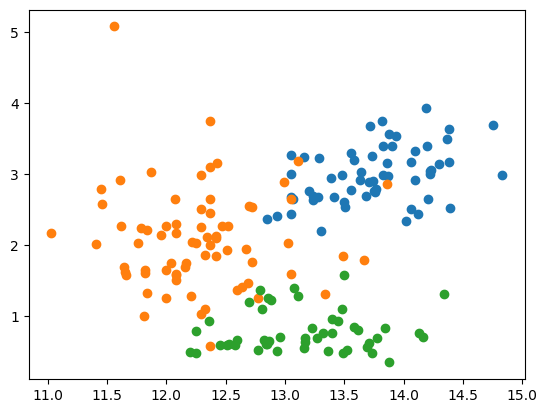

训练得分： 0.9172932330827067
测试得分： 0.8666666666666667


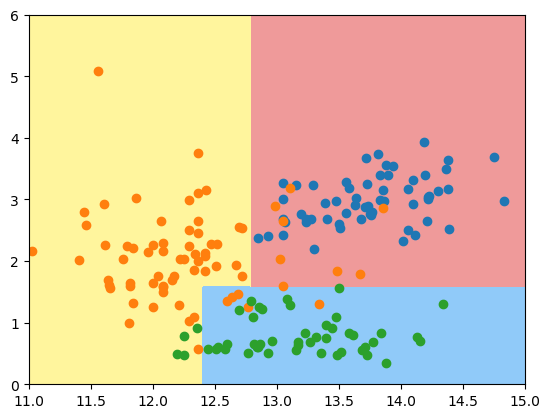

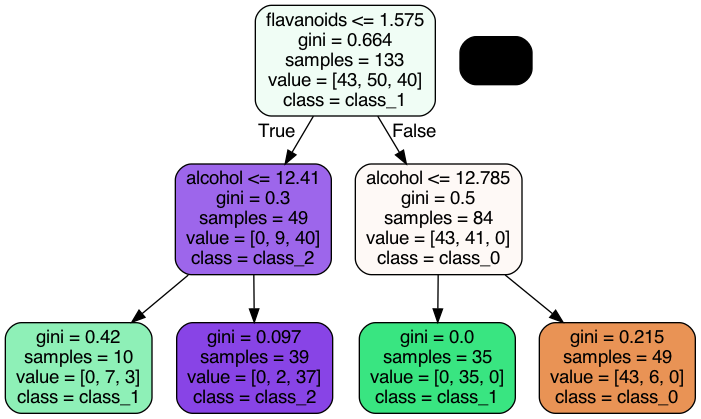

In [12]:
########################（2）加载数据
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
 
# 加载葡萄酒的数据集
wine = datasets.load_wine()
 
# 为了方便可视化，只选取 2 个特征
X = wine.data[:, [0, 6]]
y = wine.target
 
# 绘制散点图
plt.scatter(X[y==0, 0], X[y==0, 1])
plt.scatter(X[y==1, 0], X[y==1, 1])
plt.scatter(X[y==2, 0], X[y==2, 1])
plt.show()

########################（3）调用算法
from sklearn.model_selection import train_test_split
from sklearn import tree
 
# 拆分为训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)
 
# 调用决策树分类算法
dtc = tree.DecisionTreeClassifier(max_depth=2)
dtc.fit(X_train, y_train)
 
# 算法评分
print('训练得分：', dtc.score(X_train, y_train))
print('测试得分：', dtc.score(X_test, y_test))


########################（4）决策边界
from matplotlib.colors import ListedColormap
 
# 定义绘制决策边界的函数
def plot_decision_boundary(model, axis):
    
    x0, x1 = np.meshgrid(
        np.linspace(axis[0], axis[1], int((axis[1]-axis[0])*100)).reshape(-1,1),
        np.linspace(axis[2], axis[3], int((axis[3]-axis[2])*100)).reshape(-1,1)
    )
    X_new = np.c_[x0.ravel(), x1.ravel()]
    
    y_predict = model.predict(X_new)
    zz = y_predict.reshape(x0.shape)
    
    custom_cmap = ListedColormap(['#EF9A9A','#FFF59D','#90CAF9'])
    
    plt.contourf(x0, x1, zz, cmap=custom_cmap)
    
# 绘制决策边界
plot_decision_boundary(dtc, axis=[11, 15, 0, 6])
plt.scatter(X[y==0, 0], X[y==0, 1])
plt.scatter(X[y==1, 0], X[y==1, 1])
plt.scatter(X[y==2, 0], X[y==2, 1])
plt.show()
      
########################（4）树状图
# 导入相关库，需要先安装 graphviz 和 pydotplus，并在电脑中 Graphviz 软件
import pydotplus
from sklearn.tree import export_graphviz
from IPython.display import Image
from io import StringIO
 
# 将对象写入内存中
dot_data = StringIO()
 
# 生成决策树结构
tree.export_graphviz(dtc, class_names=wine.target_names,
                     feature_names=[wine.feature_names[0], wine.feature_names[6]],
                     rounded=True, filled=True, out_file = dot_data)
 
# 生成树形图并展示出来
graph = pydotplus.graph_from_dot_data(dot_data.getvalue())
Image(graph.create_png())
